# Warren's Notebook: Condemned Properties

## Introduction

For this project I am looking at structural safety as my sub-metric for the best neighborhood in Pittsburgh. The dataset I am using is the Condemned and Dead-End Properties dataset from the WPRDC, which is maintained by Pittsburgh's Department of Permits, Licenses, and Inspections. It contains every condemned property in the city along with an inspection score that rates how bad each one is.

A neighborhood where buildings are falling apart is not a good neighborhood to live in. Condemned properties signal neglect and real physical danger. Going in I thought Squirrel Hill would probably come out on top since it is generally considered one of the better neighborhoods in the city.

## The Metric

When PLI inspects a condemned property they assign it a latest_inspection_score on a scale starting from 0. A higher score means the property is in worse condition. A lower score means it is in better shape.

My sub-metric is the average latest_inspection_score across all condemned properties in a neighborhood. A lower average means the condemned properties there are in relatively better condition, so I am treating that as the safer and better maintained neighborhood.

One thing worth noting is that this dataset only includes neighborhoods that have at least one condemned property. A neighborhood with zero condemned properties would actually be the safest by this logic but it will not show up here.

## Data Loading

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the condemned properties CSV from the shared data folder
df = pd.read_csv("data/condemned_properties.csv", low_memory=False)
df.head()

,_id,parcel_id,address,zip_code,owner,property_type,create_date,latest_inspection_result,latest_inspection_score,record_number,inspection_status,latitude,longitude,neighborhood,council_district,ward
0,79366,0015L00194000000,"113 CHALFONT ST, Pittsburgh, 15210",15210,JAMES CHARMETTE Y,Condemned/Dead End Property,2020-08-26,Fail,2.0,0015L00194000000,Active,40.416790,-80.005301,Beltzhoover,3,18
1,79367,0015L00194000000,"113 CHALFONT ST, Pittsburgh, 15210",15210,JAMES CHARMETTE Y,Condemned/Dead End Property,2024-01-04,Pass,0.0,0015L00194000000,Active,40.416790,-80.005301,Beltzhoover,3,18
2,79368,0232B00068000000,"1825 MAPLEWOOD AVE, Pittsburgh, 15221",15221,SLOAN MALCOLM & LILLIAN,Condemned/Dead End Property,2024-02-07,NaN,NaN,0232B00068000000,Active,40.452078,-79.878020,East Hills,9,13
3,79369,0232B00068000000,"1825 MAPLEWOOD AVE, Pittsburgh, 15221",15221,SLOAN MALCOLM & LILLIAN,Condemned/Dead End Property,2024-02-07,Fail,1.0,0232B00068000000,Active,40.452078,-79.878020,East Hills,9,13
4,79370,0011A00235000000,No primary address specified,15219,BLAIR WILLIAM HOWARD,Condemned/Dead End Property,2020-12-03,Pass,0.0,0011A00235000000,Active,40.441262,-79.979691,Crawford-Roberts,6,3


## Data Preparation

In [6]:
clean_df = df.dropna(subset=['latest_inspection_score', 'neighborhood']).copy()

# Calculate the average inspection score for each neighborhood
neighborhood_stats = clean_df.groupby('neighborhood')['latest_inspection_score'].mean().reset_index()
neighborhood_stats.columns = ['neighborhood', 'avg_score']

# Sort so the safest neighborhood is first
neighborhood_stats = neighborhood_stats.sort_values('avg_score', ascending=True).reset_index(drop=True)

neighborhood_stats.head(10)

,neighborhood,avg_score
0,Windgap,0.000000
1,Central Lawrenceville,0.500000
2,Stanton Heights,0.500000
3,Highland Park,0.500000
4,Mt. Oliver,0.500000
5,South Oakland,0.625000
6,Terrace Village,0.666667
7,Brighton Heights,0.714286
8,Lincoln Place,0.727273
9,California-Kirkbride,0.727273


## Analysis

The chart below shows the 10 neighborhoods with the lowest average inspection scores. A shorter bar means the condemned properties in that neighborhood are in better condition, which I am using as a stand-in for overall structural safety.

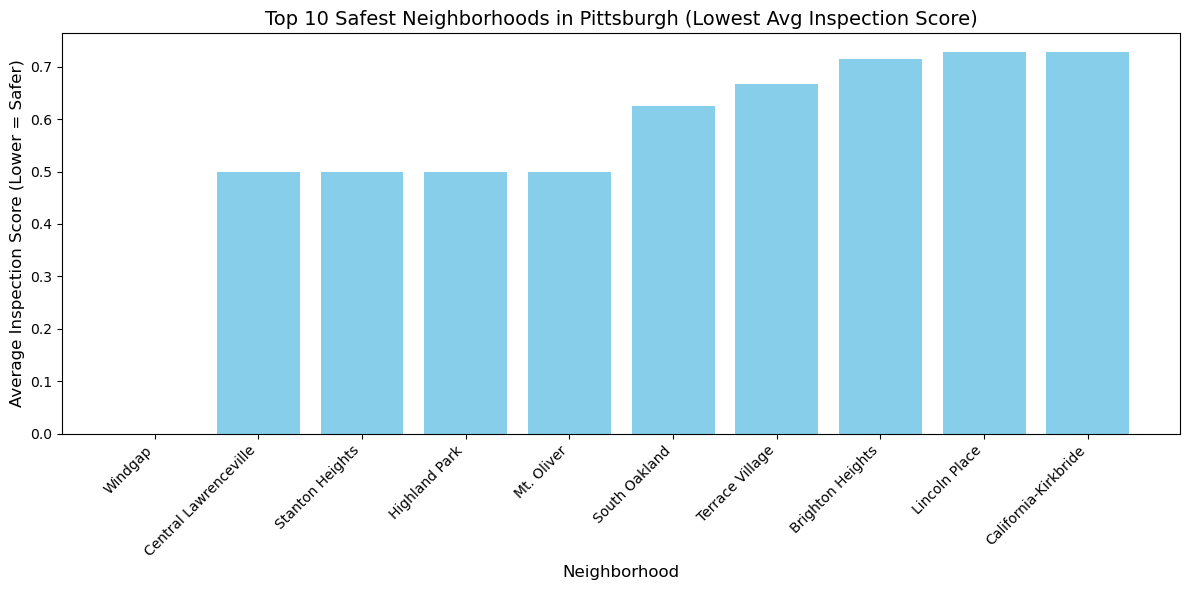

In [12]:
top10 = neighborhood_stats.head(10)

plt.figure(figsize=(12, 6))
plt.bar(top10['neighborhood'], top10['avg_score'], color='skyblue')

plt.title('Top 10 Safest Neighborhoods in Pittsburgh (Lowest Avg Inspection Score)', fontsize=14)
plt.xlabel('Neighborhood', fontsize=12)
plt.ylabel('Average Inspection Score (Lower = Safer)', fontsize=12)

# Rotate labels so long neighborhood names don't overlap
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

The chart shows the 10 neighborhoods with the lowest amount of condemned properties. Based on the given data, these properties are deemed the safest.

In [14]:
# Print the winner
best = neighborhood_stats.iloc[0]
print(f"Safest neighborhood: {best['neighborhood']}")
print(f"Average inspection score: {best['avg_score']:.2f}")

Safest neighborhood: Windgap
Average inspection score: 0.00


## Results

After analyzing the data it appears that there is one neighborhood with a perfect score. This means all of the condemned properties in this neighborhood recieved a perfect score on the latest_inspection_score scale from 0 to 62. This means **Windgap** is the safest neighborhood by my metric.

## Conclusion

Using the average inspection score as my sub-metric, the neighborhood with the lowest score is the safest by this measure. What surprised me doing this analysis is that the data does not always line up with what you would expect. I thought Squirrel Hill would score higher on this ranking. Some neighborhoods that have a good reputation still show up with higher average scores than others. It is a good reminder that what people think about a neighborhood and what the data actually says are not always the same thing.